In [1]:
from torchvision import models

# 使用 ResNet101 作为主干网络，模型使用 ImageNet 预训练
pretrained_net = models.resnet101(pretrained='imagenet')

d:\DeepLearning\Anaconda\envs\deep-learning\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\DeepLearning\Anaconda\envs\deep-learning\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [2]:
import torch.nn as nn

# FCN-8s模型
class FCN8s(nn.Module):
    def __init__(self, num_classes, train_backbone=False):
        super(FCN8s, self).__init__()
        # 这里使用children()调用ResNet101的部分网络
        # 该深度特征图的大小为输入图像的1/8
        self.stage1 = nn.Sequential(*list(pretrained_net.children())[:-4])
        # 该深度特征图的大小为输入图像的1/16
        self.stage2 = list(pretrained_net.children())[-4]
        # 该深度特征图的大小为输入图像的1/32
        self.stage3 = list(pretrained_net.children())[-3]
        self.train_backbone = train_backbone

        # 默认冻结 ResNet 主干，只训练分割头，显著降低反向传播的显存占用
        if not train_backbone:
            for stage in (self.stage1, self.stage2, self.stage3):
                for parameter in stage.parameters():
                    parameter.requires_grad_(False)
        
        # 调整stage3输出的通道数
        self.scores1 = nn.Conv2d(2048, num_classes, 1)
        # 调整stage2输出的通道数
        self.scores2 = nn.Conv2d(1024, num_classes, 1)
        # 调整stage1输出的通道数
        self.scores3 = nn.Conv2d(512, num_classes, 1)
        
        # 对pool3与pool4、pool5的输出进行8倍上采样
        self.upsample_8x = nn.ConvTranspose2d(
            num_classes, num_classes, 16, 8, 4, bias=False)
        self.upsample_8x.weight.data = bilinear_kernel(
            num_classes, num_classes, 16)
        
        # 对pool4和pool5融合的特征2倍上采样
        self.upsample_4x = nn.ConvTranspose2d(
            num_classes, num_classes, 4, 2, 1, bias=False)
        self.upsample_4x.weight.data = bilinear_kernel(
            num_classes, num_classes, 4)
        
        # 对pool5的输出2倍上采样
        self.upsample_2x = nn.ConvTranspose2d(
            num_classes, num_classes, 4, 2, 1, bias=False)
        self.upsample_2x.weight.data = bilinear_kernel(
            num_classes, num_classes, 4)

    def train(self, mode=True):
        super().train(mode)
        if not self.train_backbone:
            # 冻结主干的 BatchNorm，避免 train() 修改其运行统计量
            self.stage1.eval()
            self.stage2.eval()
            self.stage3.eval()
        return self

    def forward(self, x):
        if self.train_backbone:
            x = self.stage1(x)
            s1 = x
            x = self.stage2(x)
            s2 = x
            x = self.stage3(x)
            s3 = x
        else:
            with torch.no_grad():
                x = self.stage1(x)
                s1 = x
                x = self.stage2(x)
                s2 = x
                x = self.stage3(x)
                s3 = x
                
        # 调整pool5输出特征图的通道数并上采样
        s3 = self.upsample_2x(self.scores1(s3))
        # 融合pool5、pool4的特征图
        s2 = self.upsample_4x(self.scores2(s2) + s3)
        # 融合pool3特征并恢复到原图大小
        s = self.scores3(s1) + s2
        return self.upsample_8x(s)
    

In [3]:
import os
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import transforms as tfs


In [4]:
voc_root = r"C:\Users\17934\Desktop\Artificial-Intelligence\3-Resources\Codes\DataSet\Figure\VOCdevkit\VOC2012"

# 定义Pascal Voc类
class VOCSegDataset(Dataset):
    def __init__(self, train, crop_size, transforms):
        # 定义数据大小
        self.crop_size = crop_size
        # 定义数据增强类型
        self.transforms = transforms
        
        # 数据以及对应标签的读取
        data_list, label_list = read_images(voc_root, train=train)
        self.data_list = self._filter(data_list)
        self.label_list = self._filter(label_list)
        print('Read'+str(len(self.data_list))+'images')
        
    def _filter(self, images):
        return [im for im in images if 
                (Image.open(im).size[1] >= self.crop_size[0] and
                Image.open(im).size[0] >= self.crop_size[1])]
    # 定义数据如何进行传输
    def __getitem__(self,idx):
        img = self.data_list[idx]
        label = self.label_list[idx]
        # 读取图像
        img = cv2.imread(img)
        # 将图像通道从BGR转换成RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        label = cv2.imread(label)
        # 因为标签与像素点一一对应，因此也需要将其进行转换
        label = cv2.cvtColor(label, cv2.COLOR_BGR2RGB)
        # 进行数据增强
        img,label = self.transforms(img, label, self.crop_size)
        return img, label
    
    def __len__(self):
        return len(self.data_list)

我们对上述类中出现的部分函数进行实现。

In [5]:
# 对上述数据集类的方法进行实现

# 读取数据集
def read_images(root, train=True):
    txt_filename = root + "/ImageSets/Segmentation/" \
        + ('train.txt' if train else 'val.txt')
    with open(txt_filename, 'r') as f:
        images = f.read().split()
    data = [os.path.join(root, 'JPEGImages', i + '.jpg') 
                                    for i in images]
    label = [os.path.join(root, 'SegmentationClass', i+'.png') 
                                    for i in images]
    return data, label


# 进行随机裁剪
def rand_crop(data, label, height,width):
    h, w, _ = data.shape
    top = random.randint(0, h - height)
    left = random.randint(0, w - width)
    # 裁剪数据
    data = data[top:top + height, left:left + width]
    # 裁剪标签
    label = label[top:top + height, left:left + width]
    return data, label


# 为图像增强时的像素点建立对应的标签
def image2label(im):
    data = np.array(im, dtype='int32')
    idx = (data[:,:,0] * 256 + data[:,:,1]) * 256 + data[:,:,2]
    return np.array(cm2lbl[idx], dtype='int64')


# 定义数据增强方法
def img_transforms(im, label, crop_size):
    im,label = rand_crop(im, label, *crop_size)
    im_tfs = tfs.Compose([
        tfs.ToTensor(),
        tfs.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    im = im_tfs(im)
    label = image2label(label)
    label = torch.from_numpy(label)
    return im, label



# 删除双线性插值函数中的输出
def bilinear_kernel(in_channels, out_channels, kernel_size):
    factor = (kernel_size + 1) // 2
    if kernel_size % 2 == 1:
        center = factor - 1
    else:
        center = factor - 0.5
    og = np.ogrid[:kernel_size, :kernel_size]
    filt = (1 - abs(og[0] - center) / factor) * \
        (1 - abs(og[1] - center) / factor)
    weight = np.zeros((in_channels, out_channels,
                       kernel_size, kernel_size), dtype='float32')
    weight[range(in_channels), range(out_channels),:,:] = filt
    return torch.from_numpy(weight)


In [6]:
# Pascal Voc的类别
classes = ['background','aeroplane','bicycle','bird','boat',
           'bottle','bus','car','cat','chair','cow','diningtable',
           'dog','horse','motorbike','person','potted plant',
           'sheep','sofa','train','tv/monitor']

# colormap的数量与类别数对应，每一种类别都有其独一无二的颜色，便于绘制图像时进行观察
colormap = [[0,0,0], [128,0,0], [0,128,0], [128,128,0], [0,0,128],
            [128,0,128], [0,128,128], [128,128,128], [64,0,0], 
            [192,0,0], [64,128,0], [192,128,0], [64,0,128], 
            [192,0,128], [64,128,128], [192,128,128], [0,64,0], 
            [128,64,0], [0,192,0], [128,192,0], [0,64,128]]

# 读取数据和标签
data, label = read_images(voc_root)
num_classes = len(classes)

# 将colormap转换成类别
cm2lbl = np.zeros(256**3)
for i, cm in enumerate(colormap):
    cm2lbl[(cm[0]*256+cm[1])*256+cm[2]]=i

# 设置输入图像大小
input_shape = (320,480)
voc_train = VOCSegDataset(True, input_shape, img_transforms)
voc_test = VOCSegDataset(False, input_shape, img_transforms)

Read1114images
Read1078images


In [7]:
# 保留较大的 batch，通过冻结主干降低反向传播的显存占用
BATCH_SIZE = 32
ACCUMULATION_STEPS = 2  # 有效 batch size 约为 64
PIN_MEMORY = torch.cuda.is_available()
train_data = DataLoader(
    voc_train, batch_size=BATCH_SIZE, shuffle=True, pin_memory=PIN_MEMORY)
test_data = DataLoader(
    voc_test, batch_size=BATCH_SIZE, pin_memory=PIN_MEMORY)

先展示数据集中的部分图像与其对应的标签。

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


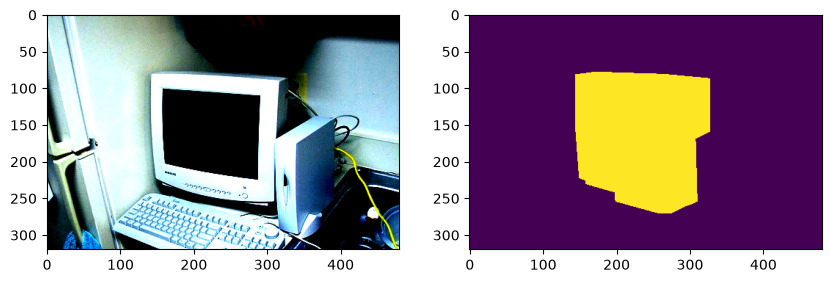

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


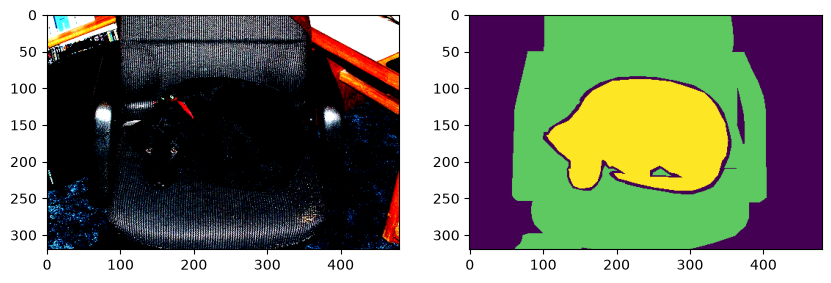

In [8]:
for i, (img, label) in enumerate(voc_train):
    plt.figure(figsize=(10, 10))
    plt.subplot(221)
    plt.imshow(img.moveaxis(0, 2))
    plt.subplot(222)
    plt.imshow(label)  
    plt.show()
    plt.close()
    if i ==1:
        break


编写相关函数实现计算 mIoU

In [9]:
def _fast_hist(label_true, label_pred, n_class):
    mask = (label_true >= 0) & (label_true < n_class)
    hist = np.bincount(
        n_class * label_true[mask].astype(int) +
        label_pred[mask], minlength=n_class ** 2).reshape(
                                                n_class, n_class)
    return hist


def mIoU(label_trues, label_preds, n_class):
    # 计算mIoU
    hist = np.zeros((n_class, n_class))
    
    for lt, lp in zip(label_trues, label_preds):
        hist += _fast_hist(lt.flatten(), lp.flatten(), n_class)
        
    iu = np.diag(hist) / (hist.sum(axis=1) + 
                          hist.sum(axis=0) - np.diag(hist))
    mean_iu = np.nanmean(iu)

    return mean_iu

加载FCN-8s模型，并对其进行训练。

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 重新运行本单元时释放上一次训练留下的模型引用
if 'model' in globals():
    del model

# 冻结 ResNet 主干，只训练 FCN 分割头，保留较大的 BATCH_SIZE
model = FCN8s(num_classes, train_backbone=False).to(device)
if device.type == 'cuda' and torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

# 冻结参数不需要优化器状态，进一步节省显存
trainable_parameters = [
    parameter for parameter in model.parameters() if parameter.requires_grad]
optimizer = torch.optim.SGD(trainable_parameters, lr=1e-2,
                            weight_decay=1e-4)

# 设置损失函数
criterion = nn.NLLLoss()


In [11]:
# 由于没有验证集，这里每训练完一次模型便在测试集上进行测试

np.seterr(divide='ignore', invalid='ignore')

Epoch = 120
for epoch in range(Epoch):
    # 训练损失
    train_loss = 0
    # 训练mIoU
    train_mean_iu = 0

    # 开始训练
    model = model.train()
    optimizer.zero_grad(set_to_none=True)

    for batch_idx, data in enumerate(train_data):
        x = data[0].to(device, non_blocking=True)
        y = data[1].to(device, non_blocking=True)

        # 获得模型预测概率分布
        # 使用自动混合精度，降低训练显存占用
        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=(device.type == 'cuda')
        ):
            outputs = model(x)
            outputs = F.log_softmax(outputs, dim=1)
            loss = criterion(outputs, y)

        # 梯度累积：小 batch 训练，减少显存峰值
        (loss / ACCUMULATION_STEPS).backward()
        if ((batch_idx + 1) % ACCUMULATION_STEPS == 0 or
                (batch_idx + 1) == len(train_data)):
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

        # 记录未缩放的损失
        train_loss += loss.item()

        # 获得预测标签
        label_pred = outputs.max(dim=1)[1].data.cpu().numpy()
        label_true = y.data.cpu().numpy()

        for lbt, lbp in zip(label_true, label_pred):
            # 返回每张图的pred和gt标签计算mIoU
            mean_iu = mIoU(lbt, lbp, num_classes)
            train_mean_iu += mean_iu

    # 测试损失
    eval_loss = 0
    # 测试mIoU
    eval_mean_iu = 0

    # 进行模型测试
    model = model.eval()

    with torch.inference_mode():
        for data in test_data:
            x_test = data[0].to(device, non_blocking=True)
            y_test = data[1].to(device, non_blocking=True)
            outputs_test = model(x_test)
            outputs_test = F.log_softmax(outputs_test, dim=1)

            loss = criterion(outputs_test, y_test)
            eval_loss += loss.item()

            label_pred = outputs_test.max(dim=1)[1].data.cpu().numpy()
            label_true = y_test.data.cpu().numpy()

            for lbt, lbp in zip(label_true, label_pred):
                mean_iu = mIoU(lbt, lbp, num_classes)
                eval_mean_iu += mean_iu

    epoch_str = ('Epoch: {}, Train Loss: {:.5f}, Train Mean IU: {:.5f}, '
                 'Valid Loss: {:.5f}, Valid Mean IU: {:.5f}'.format(
                    epoch, train_loss / len(train_data),
                    train_mean_iu / len(voc_train),
                    eval_loss / len(test_data),
                    eval_mean_iu / len(voc_test)))

    print(epoch_str)


Epoch: 0, Train Loss: 1.75045, Train Mean IU: 0.29209, Valid Loss: 1.39840, Valid Mean IU: 0.29931
Epoch: 1, Train Loss: 1.29716, Train Mean IU: 0.28767, Valid Loss: 1.23918, Valid Mean IU: 0.26968
Epoch: 2, Train Loss: 1.25497, Train Mean IU: 0.28780, Valid Loss: 1.25947, Valid Mean IU: 0.28675
Epoch: 3, Train Loss: 1.73795, Train Mean IU: 0.27685, Valid Loss: 1.38372, Valid Mean IU: 0.32566
Epoch: 4, Train Loss: 2.73055, Train Mean IU: 0.25178, Valid Loss: 1.75926, Valid Mean IU: 0.32191
Epoch: 5, Train Loss: 3.95318, Train Mean IU: 0.24650, Valid Loss: 5.81673, Valid Mean IU: 0.31723
Epoch: 6, Train Loss: 5.87980, Train Mean IU: 0.24198, Valid Loss: 5.78265, Valid Mean IU: 0.31720
Epoch: 7, Train Loss: 5.82863, Train Mean IU: 0.24957, Valid Loss: 3.02960, Valid Mean IU: 0.32342
Epoch: 8, Train Loss: 6.20057, Train Mean IU: 0.23108, Valid Loss: 6.26049, Valid Mean IU: 0.31744
Epoch: 9, Train Loss: 8.05347, Train Mean IU: 0.23206, Valid Loss: 3.33600, Valid Mean IU: 0.22589
Epoch: 10,

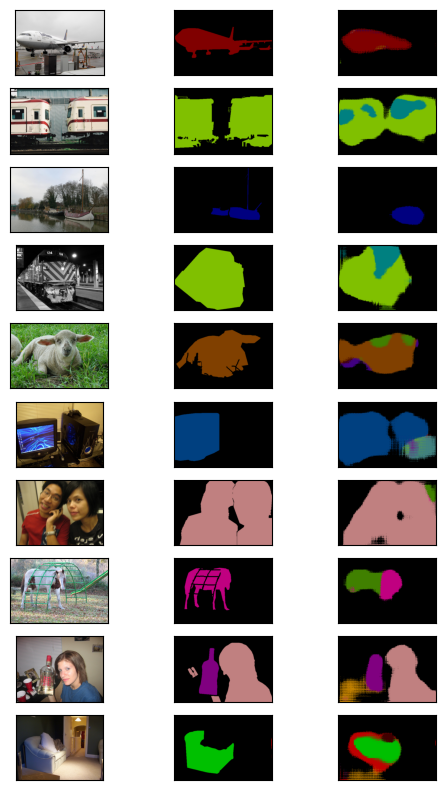

In [16]:
# 将预测的标签映射到colormap上
cm = np.array(colormap).astype('uint8')

def predict(im, label):
    im = im.unsqueeze(0).to(device)
    with torch.inference_mode():
        out = model(im)
    pred = out.max(1)[1].squeeze().cpu().numpy()
    pred = cm[pred]
    return pred, cm[label.cpu().numpy()]

_, figs = plt.subplots(10, 3, figsize=(6, 10))

for i in range(10):
    x, y = voc_test[i]
    x.to(device)
    y.to(device)
    pred, label = predict(x, y)
    figs[i, 0].imshow(Image.open(voc_test.data_list[i]))
    figs[i, 0].axes.get_xaxis().set_visible(False)
    figs[i, 0].axes.get_yaxis().set_visible(False)
    figs[i, 1].imshow(label)
    figs[i, 1].axes.get_xaxis().set_visible(False)
    figs[i, 1].axes.get_yaxis().set_visible(False)
    figs[i, 2].imshow(pred)
    figs[i, 2].axes.get_xaxis().set_visible(False)
    figs[i, 2].axes.get_yaxis().set_visible(False)